In [1]:
import pandas as pd

train_df = pd.read_csv("data/processed/train.csv")
test_df = pd.read_csv("data/processed/test.csv")
validation_df = pd.read_csv("data/processed/validation.csv")

# join all df
df = pd.concat([train_df, test_df, validation_df], ignore_index=True)

# filter to only include where
day_in_seconds = 3600 * 24
df = df[df["tweet_age"] >= day_in_seconds]
df.head()

,verified,is_blue_verified,tweet_created_at_user_created_at_diff_log,tweet_age_sigmoid,tweet_age,tweet_created_at_hour,tweet_created_at_day_of_week,tweet_created_at_hour_sin,tweet_created_at_hour_cos,tweet_created_at_day_of_week_sin,...,user_followers_to_following_ratio_log,input_text,tweet_char_len,tweet_word_len,description_word_len,username_len,has_hashtag,has_url,has_mention,target
0,0,1,8.367278,1.0,630628,19,4,-0.965926,2.588190e-01,-0.433884,...,1.900149,Username: Joltz_btc\nUser Description: 🛠️ Tool...,245,35,25,9,0,1,1,2.346353
1,0,1,8.125524,1.0,659439,6,5,1.000000,6.123234e-17,-0.974928,...,0.997978,Username: BitcoinZac\nUser Description: Web3 g...,21,3,18,10,0,0,1,1.041393
5,0,1,6.978939,1.0,518859,18,0,-1.000000,-1.836970e-16,0.000000,...,1.822894,Username: ArtificialCZ\nUser Description: Firs...,160,24,11,12,0,0,1,2.164353
7,0,1,8.086956,1.0,963316,6,3,1.000000,6.123234e-17,0.433884,...,2.148806,Username: BTC_for_Freedom\nUser Description: F...,210,38,6,15,0,0,0,4.387728
9,0,1,7.929368,1.0,591366,21,3,-0.707107,7.071068e-01,0.433884,...,1.259968,Username: Manu08514934\nUser Description: Huma...,206,33,24,12,1,0,1,1.518514


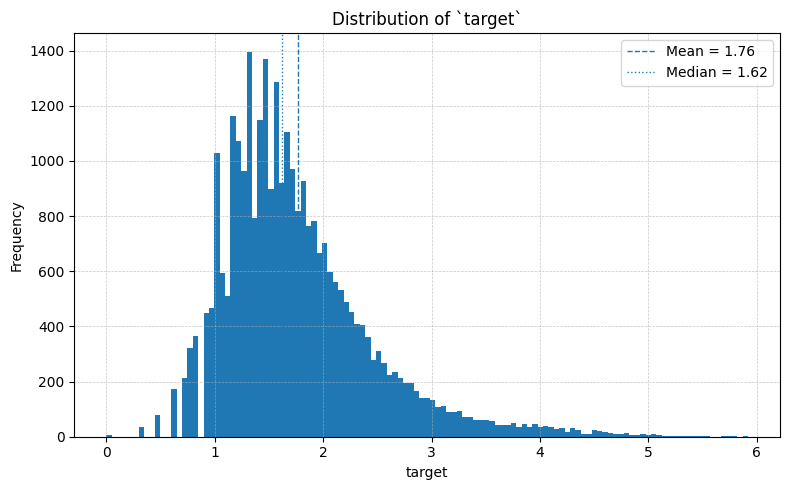

In [2]:
import matplotlib.pyplot as plt

def plot_target_distribution(df, column: str = "target") -> None:
    """
    Visualize the distribution of a numeric column with helpful context.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the column to plot.
    column : str
        Name of the numeric column whose distribution you want to inspect.
    """
    # Drop missing values and cache the series for convenience
    series = df[column].dropna()

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(8, 5))

    # Histogram with an adaptive bin count
    ax.hist(series, bins="auto")             # no explicit color → uses default
    ax.set_title(f"Distribution of `{column}`")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

    # Add mean and median reference lines
    mean_val = series.mean()
    median_val = series.median()
    ax.axvline(mean_val,   linestyle="--", linewidth=1, label=f"Mean = {mean_val:.2f}")
    ax.axvline(median_val, linestyle=":",  linewidth=1, label=f"Median = {median_val:.2f}")

    ax.legend()
    plt.tight_layout()
    plt.show()

plot_target_distribution(df)


In [3]:
import asyncio
from datetime import datetime
import twikit
import time
from accounts.model import Account
from account_client import get_account, return_account   # assuming the names
from pathlib import Path
from typing import Dict, List, Tuple, Any, Union
from twikit.errors import TooManyRequests, AccountSuspended, AccountLocked, Unauthorized
import db_utils
import random
import pandas as pd
import yaml
from preprocess import _simple_v2
import joblib
from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBRegressor  # type: ignore
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import sys
RATE_LIMITS: Dict[str, List[float]] = {}
RATE_LIMIT_WINDOW: int = 15 * 60  # 15 minutes in seconds
config_path = Path("config.yaml")
config = yaml.safe_load(config_path.read_text()) or {}
engagement_model = joblib.load("models/engagement/model.joblib")
engagement_embedder = SentenceTransformer(config["train_regressor"]["embedding"]["sentence_transformers"]["model_name"])

/Users/mahdikhemakhem/Desktop/github/tweet-impact-predictor/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Cellar/python@3.12/3.12.10/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pickle.py:1760: UserWarning: [01:08:17] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:384: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/opt/homebrew/Cellar/python@3.12/3.12.10/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pickle.py:1760: UserWarning: [01:08:17] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  setstate(state)


In [10]:
from tqdm import tqdm
predicted = []

def engagement_predict(df: pd.DataFrame, model: XGBRegressor, embedder: SentenceTransformer) -> float:
    """
    Return the engagement-score prediction for every row in *df*.
    Expects the columns ``target`` and ``input_text`` to be present.
    """

    # ------------------------------------------------------------------
    # 1) Separate the columns we need
    # ------------------------------------------------------------------
    text_series = df.pop("input_text")            # keep the text separately
    if "target" in df.columns:                    # drop the training target
        df = df.drop(columns=["target"])

    # ------------------------------------------------------------------
    # 2) Numeric features – make sure everything is float
    # ------------------------------------------------------------------
    numeric_np = df.select_dtypes(exclude=["object"]).to_numpy(dtype=float)
    numeric_sparse = csr_matrix(numeric_np)       # shape = (n_rows, n_numeric)

    # ------------------------------------------------------------------
    # 3) Sentence-Transformer embeddings
    #    • always pass a *list* of str
    #    • ask for NumPy
    # ------------------------------------------------------------------
    embeddings = embedder.encode(
        text_series.tolist(),                     # <-- LIST, not ndarray
        convert_to_numpy=True,
        show_progress_bar=False
    )                                             # shape = (n_rows, emb_dim)

    if embeddings.ndim == 1:                      # happens for a single row
        embeddings = embeddings.reshape(1, -1)

    emb_sparse = csr_matrix(embeddings)           # keep everything sparse

    # ------------------------------------------------------------------
    # 4) Concatenate horizontally
    # ------------------------------------------------------------------
    combined = hstack([numeric_sparse, emb_sparse])

    # ------------------------------------------------------------------
    # 5) Predict
    # ------------------------------------------------------------------
    return float(model.predict(combined)[0])

drop_target_df = df.drop(columns=["target", "tweet_age"])
for idx, row in tqdm(drop_target_df.iterrows(), total=len(drop_target_df)):
    engagement_score = engagement_predict(pd.DataFrame([row]), engagement_model, engagement_embedder)
    predicted.append(engagement_score)

print(len(predicted))

100%|██████████| 29945/29945 [07:24<00:00, 67.34it/s]

29945


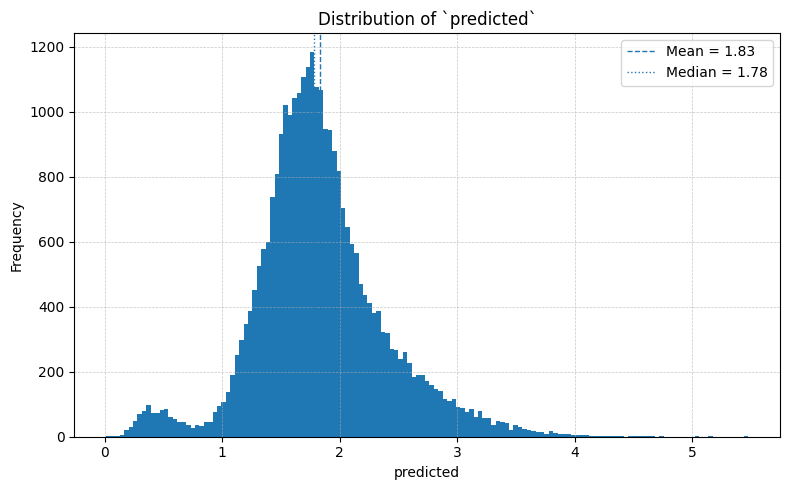

In [12]:
# make a plot of the predicted engagement scores using the helper function
plot_target_distribution(pd.DataFrame({"predicted": predicted}), "predicted")


In [15]:
# i want to get the 95th percentile of the predicted engagement scores
import numpy as np
print(np.percentile(predicted, 95))

# i want to get the percentile of a score
score = 2.88
# make sure it's a 1-D NumPy array
pred = np.asarray(predicted).ravel()

# fraction of values <= score
percentile_rank = 100.0 * np.sum(pred <= score) / pred.size
print(f"{score} is at the {percentile_rank:.2f}ᵗʰ percentile")


2.850796794891357
2.88 is at the 95.41ᵗʰ percentile


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
raw_df = pd.read_csv("data/raw.csv")
raw_df.head()

,observation_id,tweet_id,observed_at,delta_seconds,user_followers_count,user_following_count,favorite_count,retweet_count,reply_count,quote_count,...,tweet_created_at,monitor_flag,tweet_last_updated,user_id,username,user_description,verified,is_blue_verified,user_created_at,user_last_updated
0,1,1901838425566617662,1742268591,2,15,446,0,0,0,0,...,1742268589,0,1742271154,1841667777322745857,TamiCastro46818,NaN,0,0,1727922800,1742268591
1,2,1901838421485580348,1742268591,3,647,1106,0,0,0,0,...,1742268588,0,1742271164,1286497692416380928,YaboyTB,The People’s Crypto Trader,0,1,1595559937,1742268591
2,3,1901838412556185864,1742268591,5,60,1765,0,0,0,0,...,1742268586,0,1742311125,1826050097769234432,LucasChest77599,NaN,0,0,1724199265,1742371717
3,4,1901838411087954313,1742268591,5,76,204,0,0,0,0,...,1742268586,0,1742381028,1886960193558163456,ghostnodeinfo,Odin Fun Maxi. Here to document and discuss @i...,0,0,1738721351,1742268591
4,5,1901838403077132706,1742268591,7,1870,710,0,0,0,0,...,1742268584,0,1742345166,1401171905348964357,Maxsantana86,#BTC #Raidernation #RepBx,0,1,1622900403,1742268591


In [12]:
# get the int log of deltra_seconds
pd.set_option('display.max_columns', None)
raw_df.head()


,observation_id,tweet_id,observed_at,delta_seconds,user_followers_count,user_following_count,favorite_count,retweet_count,reply_count,quote_count,bookmark_count,view_count,tweet_text,tweet_created_at,monitor_flag,tweet_last_updated,user_id,username,user_description,verified,is_blue_verified,user_created_at,user_last_updated,log_deltra_seconds,log_delta_seconds
0,1,1901838425566617662,1742268591,2,15,446,0,0,0,0,0,0,#Bitcoin closed the CME gap and built a bullis...,1742268589,0,1742271154,1841667777322745857,TamiCastro46818,NaN,0,0,1727922800,1742268591,0,0
1,2,1901838421485580348,1742268591,3,647,1106,0,0,0,0,0,0,“All of the risk has been stripped out of the ...,1742268588,0,1742271164,1286497692416380928,YaboyTB,The People’s Crypto Trader,0,1,1595559937,1742268591,0,0
2,3,1901838412556185864,1742268591,5,60,1765,0,0,0,0,0,0,CatiCorn: The Only Crypto with Pawsome Energy!...,1742268586,0,1742311125,1826050097769234432,LucasChest77599,NaN,0,0,1724199265,1742371717,0,0
3,4,1901838411087954313,1742268591,5,76,204,0,0,0,0,0,0,Translation:\n“You are the network.”\n\nMeanin...,1742268586,0,1742381028,1886960193558163456,ghostnodeinfo,Odin Fun Maxi. Here to document and discuss @i...,0,0,1738721351,1742268591,0,0
4,5,1901838403077132706,1742268591,7,1870,710,0,0,0,0,0,0,@3orovik Bitcoin only apparently,1742268584,0,1742345166,1401171905348964357,Maxsantana86,#BTC #Raidernation #RepBx,0,1,1622900403,1742268591,0,0


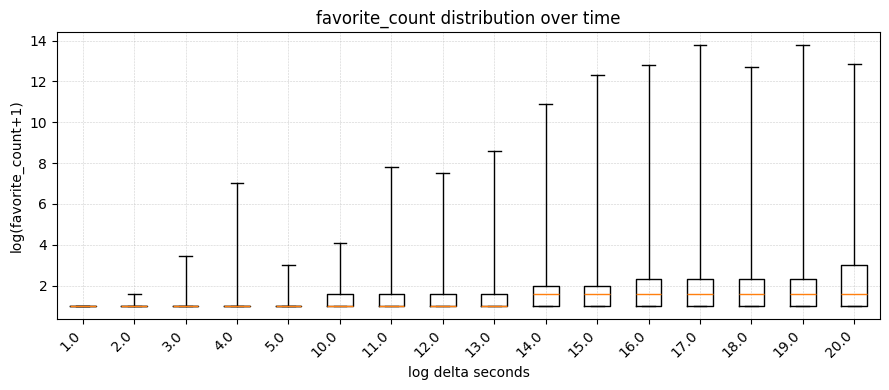

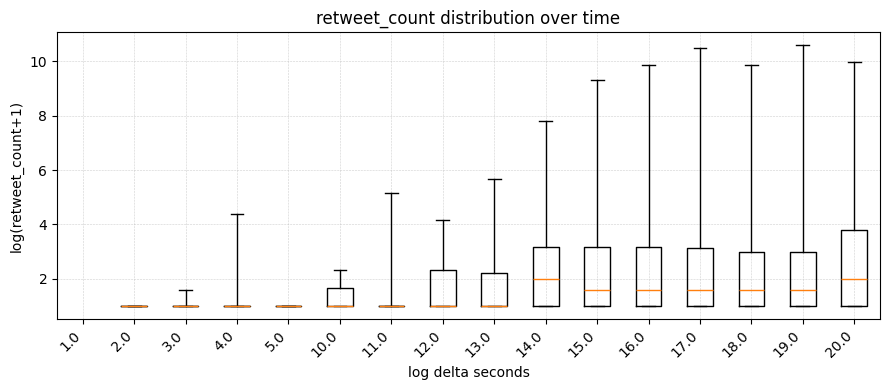

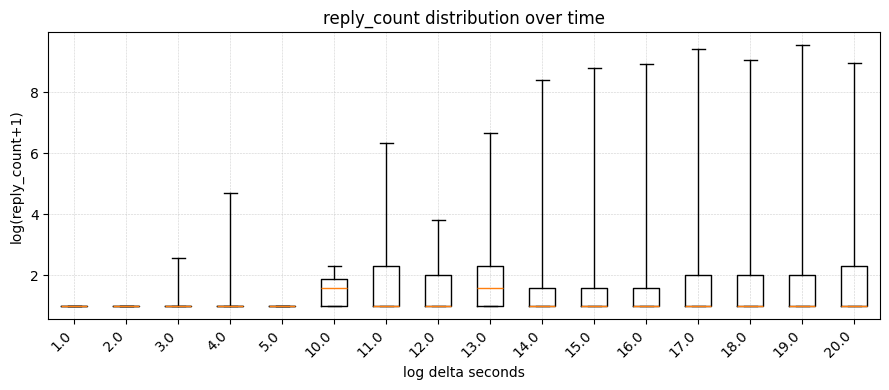

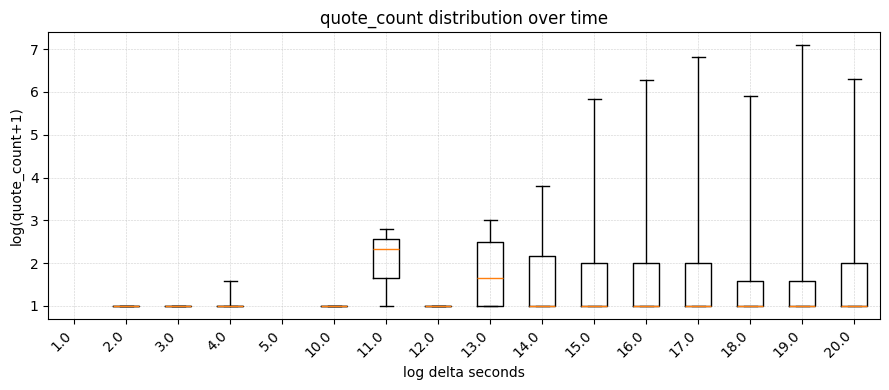

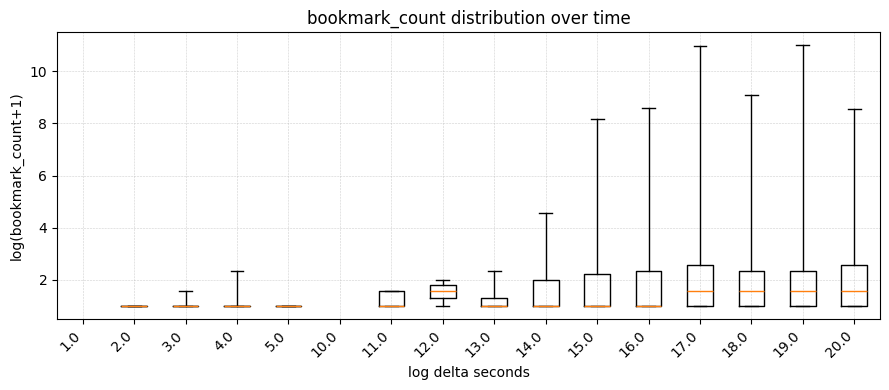

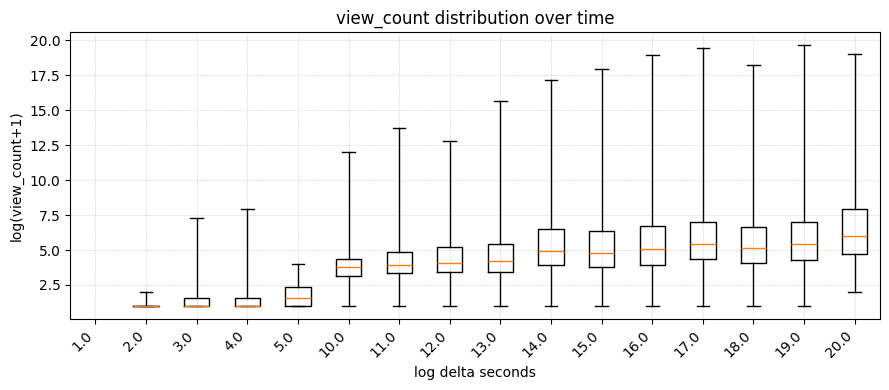

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Sequence, Mapping, Any, Iterable

def prepare_counts(
    df: pd.DataFrame,
    *,
    group_col: str = "log_delta_seconds",
    features: Sequence[str] | None = None,
) -> dict[str, dict[str, list[float]]]:
    """Convert *df* into the nested ``counts`` structure used for plotting.

    Parameters
    ----------
    df : pandas.DataFrame
        Source data containing *group_col* and *features*.
    group_col : str, default ``"log_delta_seconds"``
        Column whose **values define the x-axis time-bins**.
    features : Sequence[str] | None
        Columns to aggregate. If *None*, **all numeric columns** are used.

    Returns
    -------
    dict[str, dict[str, list[float]]]
        ``{group_label → {feature → [values…]}}`` ready for the plotting helper.
    """
    if features is None:
        features = df.select_dtypes("number").columns.tolist()

    out: dict[str, dict[str, list[float]]] = {}
    for grp, grp_df in df.groupby(group_col):
        out[grp] = {
            feat: grp_df[feat].dropna().tolist()
            for feat in features
            if feat in grp_df
        }
    return out

def _safe_log(arr: Iterable[float], eps: float = 1.0, base: float = 2) -> np.ndarray:
    """`log10(x+eps)` that works for zeros and negatives."""
    a = np.asarray(arr, dtype=float)
    a = np.where(a <= 0, np.nan, a)      # drop negatives
    return np.log(a + eps) / np.log(base)

def boxplots_by_feature(
    counts: Mapping[str, Mapping[str, Sequence[float]]],
    features: Sequence[str],
    *,
    log_scale: bool = False,             # ← same flag as before
    figsize: tuple[int, int] = (9, 4),
    sort_groups: bool = True,
    show_fliers: bool = True,
    eps: float = 1.0                     # shift so log(0) becomes log(eps)
) -> None:

    # ── reshape to long form ───────────────────────────────────────────────
    rows: list[dict[str, Any]] = [
        {"group": g, "feature": f, "value": v}
        for g, feat_d in counts.items()
        for f, vals in feat_d.items()
        for v in vals
        if not pd.isna(v)
    ]
    long_df = pd.DataFrame(rows)
    if long_df.empty:
        raise ValueError("no data available")

    # ── x-axis ordering ────────────────────────────────────────────────────
    order = (
        sorted(long_df["group"].astype(float).unique())
        if sort_groups else long_df["group"].unique()
    )
    x_map = {g: i for i, g in enumerate(order)}
    long_df["x"] = long_df["group"].map(x_map)

    # ── draw one figure per feature ───────────────────────────────────────
    for feat in features:
        sub = long_df[long_df["feature"] == feat].copy()
        if sub.empty:
            print(f"⚠️  {feat}: no data – skipping"); continue

        # optional log transform
        if log_scale:
            sub["value"] = _safe_log(sub["value"], eps=eps)
            y_label = f"log({feat}+{eps:g})"
        else:
            y_label = feat

        # gather by x-position
        vals = [sub[sub["x"] == i]["value"].dropna().values
                for i in range(len(order))]

        fig, ax = plt.subplots(figsize=figsize)
        ax.boxplot(
            vals,
            positions=np.arange(len(order)),
            whis=(0, 100),              # full range (no hidden tail)
            showfliers=show_fliers,
            flierprops=dict(marker="o", markersize=3, alpha=0.4)
        )

        # ── cosmetics ──────────────────────────────────────────────────────
        ax.set_xticks(np.arange(len(order)))
        ax.set_xticklabels([str(g) for g in order], rotation=45, ha="right")
        ax.set_xlabel("log delta seconds")
        ax.set_ylabel(y_label)
        ax.set_title(f"{feat} distribution over time")
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

        # give the tails a bit of breathing room
        ymin, ymax = np.nanmin(sub["value"]), np.nanmax(sub["value"])
        span = ymax - ymin
        ax.set_ylim(ymin - 0.05 * span, ymax + 0.05 * span)

        plt.tight_layout()
        plt.show()

FEATURES = [
    "favorite_count",
    "retweet_count",
    "reply_count",
    "quote_count",
    "bookmark_count",
    "view_count",
]
# apply safe log to delta_seconds
raw_df["log_delta_seconds"] = _safe_log(raw_df["delta_seconds"] + 1).astype(int)
counts_dict = prepare_counts(raw_df, features=FEATURES)
boxplots_by_feature(counts_dict, FEATURES, log_scale=True, show_fliers=True)


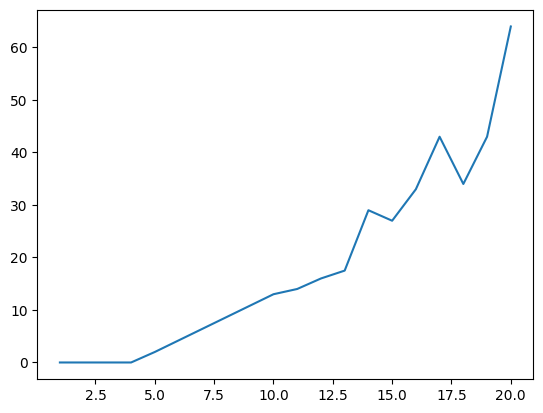

In [56]:
mean_views = {}
for group, counts in counts_dict.items():
    mean_views[group] = np.median(counts["view_count"])

# plot mean views over time
plt.plot(list(mean_views.keys()), list(mean_views.values()))
plt.show()


In [61]:
raw_df.shape

(116842, 25)

In [65]:
# min observed at
print(raw_df["observed_at"].min())
# max observed at
print(raw_df["observed_at"].max())




1742268591
1743551875
